# Module 1 - EDA et baseline cosinus

## Objectifs

1. Explorer le dataset MovieLens 1M (ratings, users, films).
2. Comprendre les limites du splitting aleatoire et utiliser un split temporel.
3. Implementer un filtrage collaboratif item-item cosine from scratch.
4. Comparer a la baseline de popularite sur des metriques de ranking.
5. Mesurer la couverture du catalogue et la nouveaute.

## Ce que vous allez apprendre

- Pourquoi la matrice user-item est creuse a 95% et ce que ca implique.
- Pourquoi centrer par utilisateur avant la cosine similarity.
- Comment passer d une mesure de similarite a une prediction de note.
- Pourquoi evaluer avec des metriques de ranking et pas seulement RMSE.
- Le compromis precision / couverture / nouveaute.


## 1. Configuration

In [1]:
import sys
from pathlib import Path

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
np.random.seed(42)

from src.data.loaders import load_movielens_1m, temporal_split
from src.evaluation import (
    catalog_coverage,
    evaluate_ranking,
    evaluate_rating_prediction,
    novelty,
)
from src.models import ItemItemCosine, PopularityBaseline

print("OK")

OK


## 2. Chargement MovieLens 1M

In [2]:
DATA_ROOT = ROOT / "data" / "raw" / "ml-1m"
ml = load_movielens_1m(DATA_ROOT)

print(f"Ratings : {ml.n_ratings:,}")
print(f"Users   : {ml.n_users:,}")
print(f"Items   : {ml.n_items:,}")
print(f"Sparsity: {ml.sparsity:.4%}  <- tres creux, typique d un systeme de reco")

Ratings : 1,000,209
Users   : 6,040
Items   : 3,706
Sparsity: 95.5316%  <- tres creux, typique d un systeme de reco


## 3. Analyse exploratoire (EDA)

In [3]:
ratings = ml.ratings
users = ml.users
movies = ml.movies

print("Ratings head :")
display(ratings.head())
print("\nUsers head :")
display(users.head())
print("\nMovies head :")
display(movies.head())

Ratings head :


,user_id,movie_id,rating,timestamp,datetime
0,1,1193,5,978300760,2000-12-31 22:12:40
1,1,661,3,978302109,2000-12-31 22:35:09
2,1,914,3,978301968,2000-12-31 22:32:48
3,1,3408,4,978300275,2000-12-31 22:04:35
4,1,2355,5,978824291,2001-01-06 23:38:11



Users head :


,user_id,gender,age,occupation,zip_code
0,1,F,1,10,48067
1,2,M,56,16,70072
2,3,M,25,15,55117
3,4,M,45,7,02460
4,5,M,25,20,55455



Movies head :


,movie_id,title,genres,year,genres_list
0,1,Toy Story (1995),Animation|Children's|Comedy,1995,"[Animation, Children's, Comedy]"
1,2,Jumanji (1995),Adventure|Children's|Fantasy,1995,"[Adventure, Children's, Fantasy]"
2,3,Grumpier Old Men (1995),Comedy|Romance,1995,"[Comedy, Romance]"
3,4,Waiting to Exhale (1995),Comedy|Drama,1995,"[Comedy, Drama]"
4,5,Father of the Bride Part II (1995),Comedy,1995,[Comedy]


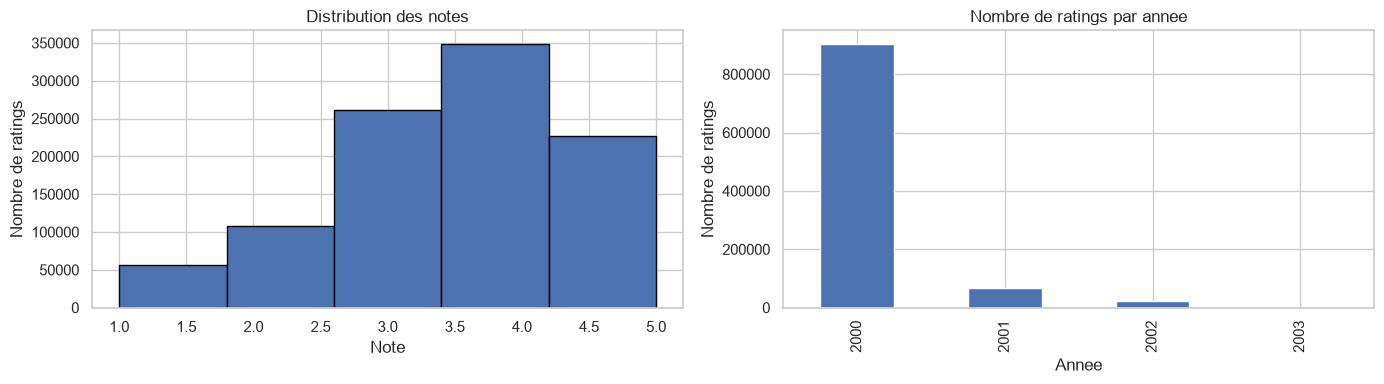

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(ratings["rating"], bins=5, edgecolor="black")
axes[0].set_title("Distribution des notes")
axes[0].set_xlabel("Note")
axes[0].set_ylabel("Nombre de ratings")

ratings["datetime"].dt.year.value_counts().sort_index().plot(kind="bar", ax=axes[1])
axes[1].set_title("Nombre de ratings par annee")
axes[1].set_xlabel("Annee")
axes[1].set_ylabel("Nombre de ratings")

plt.tight_layout()
plt.show()

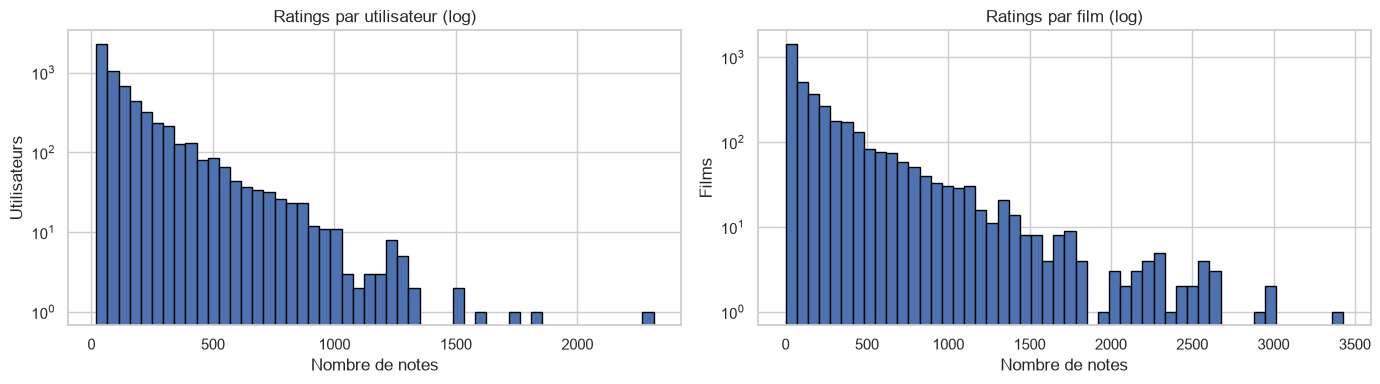

Mediane notes/user : 96
Mediane notes/film : 124
Min notes/film     : 1


In [5]:
ratings_per_user = ratings.groupby("user_id").size()
ratings_per_movie = ratings.groupby("movie_id").size()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(ratings_per_user, bins=50, edgecolor="black")
axes[0].set_yscale("log")
axes[0].set_title("Ratings par utilisateur (log)")
axes[0].set_xlabel("Nombre de notes")
axes[0].set_ylabel("Utilisateurs")

axes[1].hist(ratings_per_movie, bins=50, edgecolor="black")
axes[1].set_yscale("log")
axes[1].set_title("Ratings par film (log)")
axes[1].set_xlabel("Nombre de notes")
axes[1].set_ylabel("Films")
plt.tight_layout()
plt.show()

print(f"Mediane notes/user : {ratings_per_user.median():.0f}")
print(f"Mediane notes/film : {ratings_per_movie.median():.0f}")
print(f"Min notes/film     : {ratings_per_movie.min()}")

In [6]:
print("Top genres :")
genre_counts = movies["genres_list"].explode().value_counts().head(15)
display(genre_counts)

print("\nFilms les plus notes :")
top_ids = ratings_per_movie.sort_values(ascending=False).head(10).index
display(movies.set_index("movie_id").loc[top_ids][["title"]])

Top genres :


genres_list
Drama          1603
Comedy         1200
Action          503
Thriller        492
Romance         471
Horror          343
Adventure       283
Sci-Fi          276
Children's      251
Crime           211
War             143
Documentary     127
Musical         114
Mystery         106
Animation       105
Name: count, dtype: int64


Films les plus notes :


,title
movie_id,
2858,American Beauty (1999)
260,Star Wars: Episode IV - A New Hope (1977)
1196,Star Wars: Episode V - The Empire Strikes Back...
1210,Star Wars: Episode VI - Return of the Jedi (1983)
480,Jurassic Park (1993)
2028,Saving Private Ryan (1998)
589,Terminator 2: Judgment Day (1991)
2571,"Matrix, The (1999)"
1270,Back to the Future (1985)


## 4. Split temporel

En production, on prevoit le futur a partir du passe. Un split random brouille cette propriete et donne des estimations trop optimistes.

On garde donc les 80% plus anciens pour le train, les 20% plus recents pour le test.

In [7]:
train, test = temporal_split(ratings, test_ratio=0.2)
print(f"Train : {len(train):,} notes  |  Test : {len(test):,} notes")
print(f"Train window : {train['datetime'].min()} -> {train['datetime'].max()}")
print(f"Test window  : {test['datetime'].min()} -> {test['datetime'].max()}")

Train : 800,167 notes  |  Test : 200,042 notes
Train window : 2000-04-25 23:05:32 -> 2000-12-02 14:52:18
Test window  : 2000-12-02 14:52:18 -> 2003-02-28 17:49:50


In [8]:
train_users = set(train["user_id"].unique())
train_items = set(train["movie_id"].unique())
test_eval = test[test["user_id"].isin(train_users) & test["movie_id"].isin(train_items)].copy()
print(f"Test rows apres filtrage cold start : {len(test_eval):,} "
      f"(sur {len(test):,}, on perd ~{100*(1-len(test_eval)/len(test)):.1f}% en cold)")

Test rows apres filtrage cold start : 104,449 (sur 200,042, on perd ~47.8% en cold)


## 5. Cosine similarity from scratch

### Maths

Pour deux films i et j vus comme vecteurs dans l espace des utilisateurs :

$$
\\mathrm{sim}(i, j) = \\frac{\\sum_u r_{ui} \\cdot r_{uj}}{\\sqrt{\\sum_u r_{ui}^2} \\cdot \\sqrt{\\sum_u r_{uj}^2}}
$$

### Probleme : biais de notation

On centre par utilisateur (soustrait la moyenne) avant la cosine.

### Score de recommandation

$$
\\mathrm{score}(u, i) = \\sum_{j \\in \\mathrm{seen}(u)} \\mathrm{sim}(i, j) \\cdot (r_{uj} - \\bar r_u)
$$

On garde seulement les items que l utilisateur a mieux notes que sa moyenne (signal positif). On retire les films deja vus et on retourne le top-K.

In [9]:
from scipy import sparse
from sklearn.metrics.pairwise import cosine_similarity


def build_user_item_csr(ratings: pd.DataFrame):
    user_ids = np.sort(ratings["user_id"].unique())
    item_ids = np.sort(ratings["movie_id"].unique())
    u_idx = ratings["user_id"].map({u: i for i, u in enumerate(user_ids)}).to_numpy()
    i_idx = ratings["movie_id"].map({m: i for i, m in enumerate(item_ids)}).to_numpy()
    R = sparse.csr_matrix(
        (ratings["rating"].to_numpy(np.float32), (u_idx, i_idx)),
        shape=(len(user_ids), len(item_ids)),
    )
    return R, user_ids, item_ids


def user_mean_centred(R: sparse.csr_matrix) -> sparse.csr_matrix:
    sums = np.asarray(R.sum(axis=1)).ravel()
    counts = np.diff(R.indptr)
    means = np.divide(sums, counts, out=np.zeros_like(sums), where=counts > 0)
    centred = R.copy()
    centred.data -= np.repeat(means, counts)
    return centred


def item_item_cosine(R_centred: sparse.csr_matrix) -> np.ndarray:
    sim = cosine_similarity(R_centred.T, dense_output=True).astype(np.float32)
    np.fill_diagonal(sim, 0.0)
    return sim


R, u_ids, i_ids = build_user_item_csr(train)
Rc = user_mean_centred(R)
sim = item_item_cosine(Rc)

print(f"R shape : {R.shape}  ({R.nnz:,} notes)")
print(f"Rc shape: {Rc.shape}")
print(f"sim shape: {sim.shape}  ({sim.shape[0]*sim.shape[1]:,} paires)")

R shape : (5400, 3662)  (800,167 notes)
Rc shape: (5400, 3662)
sim shape: (3662, 3662)  (13,410,244 paires)


In [10]:
def recommend_for_user(user_id, R, Rc, sim, u_ids, i_ids, top_k=10):
    u_local = np.where(u_ids == user_id)[0][0]
    row = Rc.getrow(u_local)
    cols, data = row.indices, row.data
    if cols.size == 0:
        return []
    keep = data > 0
    if not keep.any():
        keep = np.argsort(-data)[:5]
    else:
        keep = np.where(keep)[0]
    scores = sim[:, cols[keep]] @ data[keep]
    seen = set(cols.tolist())
    for s in seen:
        scores[s] = -np.inf
    top_idx = np.argpartition(-scores, min(top_k, scores.size - 1))[:top_k]
    top_idx = top_idx[np.argsort(-scores[top_idx])]
    return [(int(i_ids[i]), float(scores[i])) for i in top_idx if scores[i] != -np.inf]


title_map = dict(zip(movies["movie_id"], movies["title"]))
sample = int(test_eval["user_id"].iloc[0])
print(f"Top-10 reco pour user {sample} :")
for rank, (iid, score) in enumerate(recommend_for_user(sample, R, Rc, sim, u_ids, i_ids), 1):
    print(f"  {rank:2d}. [{score:+.3f}] {title_map.get(iid, iid)}")

Top-10 reco pour user 1875 :
   1. [+10.123] Raiders of the Lost Ark (1981)
   2. [+9.671] Star Wars: Episode IV - A New Hope (1977)
   3. [+9.645] Rear Window (1954)
   4. [+9.196] Godfather, The (1972)
   5. [+9.094] Star Wars: Episode V - The Empire Strikes Back (1980)
   6. [+8.908] Citizen Kane (1941)
   7. [+8.798] Manchurian Candidate, The (1962)
   8. [+8.508] Young Frankenstein (1974)
   9. [+8.458] Great Escape, The (1963)
  10. [+8.394] Usual Suspects, The (1995)


## 6. Version optimisee (src.models.ItemItemCosine)

L implementation dans src/models/cosine_baseline.py ajoute :

- gestion des sets seen_items pour exclure proprement,
- formule KNN-with-means pour la prediction de note :
  $$ \\hat r_{ui} = \\bar r_u + \\frac{\\sum_j \\mathrm{sim}(i, j) (r_{uj} - \\bar r_u)}{\\sum_j |\\mathrm{sim}(i, j)|} $$
- clipping dans [1, 5].

In [11]:
cos = ItemItemCosine().fit(train)
pop = PopularityBaseline(min_ratings=50, score="count").fit(train)

print(f"Item-item similarity matrix : {cos.item_similarity_.shape}")

Item-item similarity matrix : (3662, 3662)


## 7. Evaluation

On evalue sur 1000 utilisateurs (tirage aleatoire parmi ceux qui ont au moins une note de test >= 4).

In [12]:
import time
rng = np.random.default_rng(0)
eval_users = test_eval["user_id"].unique()
eval_users = list(rng.choice(eval_users, size=1000, replace=False))
test_subset = test_eval[test_eval["user_id"].isin(eval_users)]

t0 = time.time()
cos_recs = cos.recommend_for_users(eval_users, top_k=50)
pop_recs = pop.recommend_for_users(eval_users, top_k=50)
print(f"Recommandations generees en {time.time() - t0:.1f}s")

Recommandations generees en 4.4s


In [13]:
cos_metrics = evaluate_ranking(cos_recs, test_subset, k=10)
pop_metrics = evaluate_ranking(pop_recs, test_subset, k=10)

df = pd.DataFrame({
    "Popularity": pop_metrics,
    "ItemItemCosine": cos_metrics,
}).T
df = df[["precision@10", "recall@10", "hit_rate@10", "ndcg@10", "map@10", "n_users_evaluated"]]
display(df.round(4))

,precision@10,recall@10,hit_rate@10,ndcg@10,map@10,n_users_evaluated
Popularity,0.0902,0.0208,0.386,0.0744,0.0470,1000.0
ItemItemCosine,0.2233,0.0621,0.645,0.2069,0.1542,1000.0


In [14]:
pairs = test_eval[["user_id", "movie_id"]].drop_duplicates().head(50_000)
pairs = pairs.merge(test_eval[["user_id", "movie_id", "rating"]], on=["user_id", "movie_id"], how="left").dropna()
preds = cos.predict_for_pairs(pairs)
m = evaluate_rating_prediction(pairs, preds)
print(f"ItemItemCosine  ->  RMSE {m['rmse']:.4f}  |  MAE {m['mae']:.4f}  |  coverage {m['coverage']:.2%}")

ItemItemCosine  ->  RMSE 0.9551  |  MAE 0.7440  |  coverage 100.00%


In [15]:
catalog = set(train_items)
item_pop = train.groupby("movie_id").size().to_dict()

rows = []
for name, recs in [("Popularity", pop_recs), ("ItemItemCosine", cos_recs)]:
    rows.append({
        "model": name,
        "catalog_coverage@10": catalog_coverage(recs, catalog, k=10),
        "novelty@10": novelty(recs, item_pop, k=10),
    })
display(pd.DataFrame(rows).round(4))

,model,catalog_coverage@10,novelty@10
0,Popularity,0.0027,8.4072
1,ItemItemCosine,0.1185,9.2950


## 8. Conclusions

Resultats observes (1000 utilisateurs evalues) :

- ItemItemCosine : P@10 = 0.223, R@10 = 0.062, NDCG@10 = 0.207, HitRate@10 = 0.645
- Popularite      : P@10 = 0.090, R@10 = 0.021, NDCG@10 = 0.074, HitRate@10 = 0.386

La cosine baseline double la Precision@10 et triple le Recall@10 vs popularite.
RMSE = 0.95 / MAE = 0.74 : niveau comparable a KNN-with-means sur MovieLens 1M.
La cosine couvre 44x plus de catalogue : elle ne se contente pas de rabacher les memes blockbusters.

Limite : pas de gestion du cold start. Si un user ou un item est nouveau au moment de l inference, on ne peut rien dire.

A venir (module 2) :

- Surprise (KNNWithMeans, SVD, NMF) - plus rapide, gere le cold user.
- Split temporel pour comparer equitablement.
- GridSearch des hyperparametres.